<a href="https://colab.research.google.com/github/anirbanghoshsbi/.github.io/blob/master/work/indicator/GET_FII_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyotp --q
!pip install smartapi-python==1.4.1 --q
!pip install logzero --q

In [2]:
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator,YearLocator

In [3]:
# package import statement
from SmartApi import SmartConnect #or from SmartApi.smartConnect import SmartConnect
import pyotp
from logzero import logger
import time
import os
import urllib
import json
import pandas as pd
import datetime as dt

api_key = 'HVz1H6BP'
username = 'M55123447'
pwd = '1471'
smartApi = SmartConnect(api_key)
try:
    token = "GJZACUQI2TTAIBHBA34XNFJURQ"
    totp = pyotp.TOTP(token).now()
except Exception as e:
    logger.error("Invalid Token: The provided token is not valid.")
    raise e

correlation_id = "abcde"
data = smartApi.generateSession(username, pwd, totp)

if data['status'] == False:
    logger.error(data)

else:
    # login api call
    # logger.info(f"You Credentials: {data}")
    authToken = data['data']['jwtToken']
    refreshToken = data['data']['refreshToken']
    # fetch the feedtoken
    feedToken = smartApi.getfeedToken()
    # fetch User Profile
    res = smartApi.getProfile(refreshToken)
    smartApi.generateToken(refreshToken)
    res=res['data']['exchanges']
#Download Nifty50 Index Data
params = {
           "exchange": "NSE",
           "symboltoken": '99926000',
           "interval": "ONE_DAY",
           "fromdate": (dt.datetime(2020, 9, 21).strftime('%Y-%m-%d %H:%M')),
           "todate": (dt.datetime.today().strftime('%Y-%m-%d %H:%M'))
         }
nifty_data = smartApi.getCandleData(params)
nifty_data_format= pd.DataFrame(nifty_data["data"],columns = ["Date","Open","High","Low","Close","Volume"])
nifty_data_format.set_index("Date",inplace=True)
nifty_data_format.index = pd.to_datetime(nifty_data_format.index)
nifty_data_format.index = nifty_data_format.index.tz_localize(None)

In [4]:
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.simplefilter(action='ignore', category=Warning)
import yfinance as yf

In [5]:
import numpy as np
import pandas as pd
#from pykalman import KalmanFilter
#import pandas_ta as ta

In [6]:
nif=nifty_data_format

In [7]:
nif.tail(2)

,Open,High,Low,Close,Volume
Date,,,,,
2026-05-19,23675.30,23782.3,23587.2,23618.0,0
2026-05-20,23457.25,23690.9,23397.3,23659.0,0


In [8]:
nif.head(2)
nif.reset_index(inplace=True)

In [9]:
fii=pd.read_csv('https://docs.google.com/spreadsheets/d/16JdPcqk_y9Hyiya97zBLSUfF4UNfniwDDjqPOFHjoPQ/export?format=csv')

In [10]:
# Convert both Date columns to datetime
nif["Date"] = pd.to_datetime(nif["Date"])
fii["Date"] = pd.to_datetime(fii["Date"])

# Remove timestamp part from df2
nif["Date"] = nif["Date"].dt.date
fii["Date"] = fii["Date"].dt.date

In [11]:
fii_fig = pd.merge(fii, nif, on="Date", how="inner")

# Change Here

In [12]:
fii_fig['Cash']=fii_fig.FIICash+fii_fig.DIIcash

In [13]:
fii_fig['Cashfut']=fii_fig['Cash'].ewm(span=50, adjust=False).mean()-fii_fig['Cash'].ewm(span=100, adjust=False).mean()
fii_fig['signalfutcash']=fii_fig['Cashfut'].ewm(span=22,adjust=False).mean()
fii_fig['signal10futcash']=fii_fig['Cashfut'].ewm(span=10,adjust=False).mean()

# Plot FII minus DII

In [14]:
fii_fig['macdy']=fii_fig['Cash'].ewm(span=50, adjust=False).mean()-fii_fig['Cash'].ewm(span=100, adjust=False).mean()
fii_fig['signaly']=fii_fig['macdy'].ewm(span=25,adjust=False).mean()
fii_fig['signal10y']=fii_fig['macdy'].ewm(span=10,adjust=False).mean()
fii_fig['histy']=fii_fig['macdy']-fii_fig['signaly']

In [15]:
fii_fig['macdy']=fii_fig['Cash'].ewm(span=100, adjust=False).mean()-fii_fig['Cash'].ewm(span=250, adjust=False).mean()
fii_fig['signaly']=fii_fig['macdy'].ewm(span=45,adjust=False).mean()
fii_fig['signal10y']=fii_fig['macdy'].ewm(span=20,adjust=False).mean()
fii_fig['histy']=fii_fig['macdy']-fii_fig['signaly']

In [16]:
fii_fig['macd']=fii_fig['DIIcash'].ewm(span=50, adjust=False).mean()-fii_fig['DIIcash'].ewm(span=200, adjust=False).mean()
fii_fig['signal']=fii_fig['macd'].ewm(span=35,adjust=False).mean()
fii_fig['signal10']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['hist']=fii_fig['macd']-fii_fig['signal']

In [17]:
fii_fig['macdx']=fii_fig['FIICash'].ewm(span=50, adjust=False).mean()-fii_fig['FIICash'].ewm(span=200, adjust=False).mean()
fii_fig['signalx']=fii_fig['macdx'].ewm(span=35,adjust=False).mean()
fii_fig['signal10x']=fii_fig['macdx'].ewm(span=10,adjust=False).mean()
fii_fig['histx']=fii_fig['macdx']-fii_fig['signalx']

# Plot FII , DII , Difference comparison

In [18]:
fii_fig['macd']=fii_fig['FIICash'].ewm(span=20, adjust=False).mean()-fii_fig['FIICash'].ewm(span=200, adjust=False).mean()
fii_fig['signal']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['signal10']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['hist']=fii_fig['macd']-fii_fig['signal']


In [19]:
fii_fig['macd_dom']=fii_fig['DIIcash'].ewm(span=20, adjust=False).mean()-fii_fig['DIIcash'].ewm(span=200, adjust=False).mean()
fii_fig['signal_dom']=fii_fig['DIIcash'].ewm(span=10,adjust=False).mean()
fii_fig['signal_dom_10']=fii_fig['DIIcash'].ewm(span=10,adjust=False).mean()
fii_fig['hist_dom']=fii_fig['macd_dom']-fii_fig['signal_dom']

In [20]:
nif.reset_index(inplace=True)
fii_fig.reset_index(inplace=True)
# Convert the 'Date' column in both DataFrames to the same data type
nif['Date'] = pd.to_datetime(nif['Date'])
fii_fig['Date'] = pd.to_datetime(fii_fig['Date'])

# Merge nif and fii_fig DataFrames on the 'Date' column
merged_df = pd.merge(nif, fii_fig, on='Date')


In [21]:
fii_fig['MA200']=fii_fig.Close.rolling(window=200).mean()
fii_fig['MA20']=fii_fig.Close.rolling(window=20).mean()
fii_fig['MA13']=fii_fig.Close.rolling(window=13).mean()
fii_fig['MA26']=fii_fig.Close.rolling(window=26).mean()
fii_fig['MA12']=fii_fig.Close.ewm(span=12,adjust=False).mean()
# --------------------------
# MACD
# --------------------------
fii_fig["macd_impulse"] = fii_fig["MA12"] - fii_fig["MA26"]

# MACD Signal
fii_fig["macd_signal"] = fii_fig["macd_impulse"].ewm(span=9, adjust=False).mean()

# MACD Histogram
fii_fig["macd_hist"] = fii_fig["macd_impulse"] - fii_fig["macd_signal"]

In [22]:
fii_fig["ema_slope"] = fii_fig["MA13"].diff()
fii_fig["macd_slope"] = fii_fig["macd_hist"].diff()

fii_fig["impulse"] = "blue"

fii_fig.loc[
    (fii_fig["ema_slope"] > 0) & (fii_fig["macd_slope"] > 0),
    "impulse"
] = "green"

fii_fig.loc[
    (fii_fig["ema_slope"] < 0) & (fii_fig["macd_slope"] < 0),
    "impulse"
] = "red"

In [23]:
fii_fig.columns

Index(['index', 'Date', 'FIICash', 'DIIcash', 'Open', 'High', 'Low', 'Close',
       'Volume', 'Cash', 'Cashfut', 'signalfutcash', 'signal10futcash',
       'macdy', 'signaly', 'signal10y', 'histy', 'macd', 'signal', 'signal10',
       'hist', 'macdx', 'signalx', 'signal10x', 'histx', 'macd_dom',
       'signal_dom', 'signal_dom_10', 'hist_dom', 'MA200', 'MA20', 'MA13',
       'MA26', 'MA12', 'macd_impulse', 'macd_signal', 'macd_hist', 'ema_slope',
       'macd_slope', 'impulse'],
      dtype='object')

# Plot Smart Money (FII)

In [24]:
from plotly.subplots import make_subplots
df=fii_fig.reset_index()
nif.reset_index(inplace=True)
fig = make_subplots(
    rows=2, cols=1,shared_xaxes=True,vertical_spacing=0.02,
    subplot_titles=("Smart Money","Nifty"))

fig.add_trace(go.Scatter(x=df.Date, y=df['macd'], mode='lines', name = 'macd'),
              row=1, col=1)

fig.add_trace(go.Scatter(x=df.Date, y=df['signal'], mode='lines', name = 'signal'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df.Date, y=df['signal10'], mode='lines', name = 'signal10'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=nif.Date, y=nif['Close'], mode='lines', name = 'Close'),
              row=2, col=1)

fig.update_layout(title_text="Smart Money And Nifty")

fig.show()

In [25]:
from plotly.subplots import make_subplots
df=fii_fig.reset_index()
#nif.reset_index(inplace=True)
fig = make_subplots(
    rows=2, cols=1,shared_xaxes=True,vertical_spacing=0.02,
    subplot_titles=("Smart Money DII","Nifty"))

fig.add_trace(go.Scatter(x=df.Date, y=df['macd_dom'], mode='lines', name = 'macd'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df.Date,y=df['macd_dom'].rolling(window=10).mean(),mode='lines',name='moving-average 10'),
              row=1, col=1)

fig.add_trace(go.Scatter(x=nif.Date, y=nif['Close'], mode='lines', name = 'Close'),
              row=2, col=1)

fig.update_layout(title_text="DII Money And Nifty")

fig.show()

In [68]:
fii_fig['macd_z'] = -(
    fii_fig['macd'] - fii_fig['macd'].rolling(30).mean()
) / fii_fig['macd'].rolling(30).std()

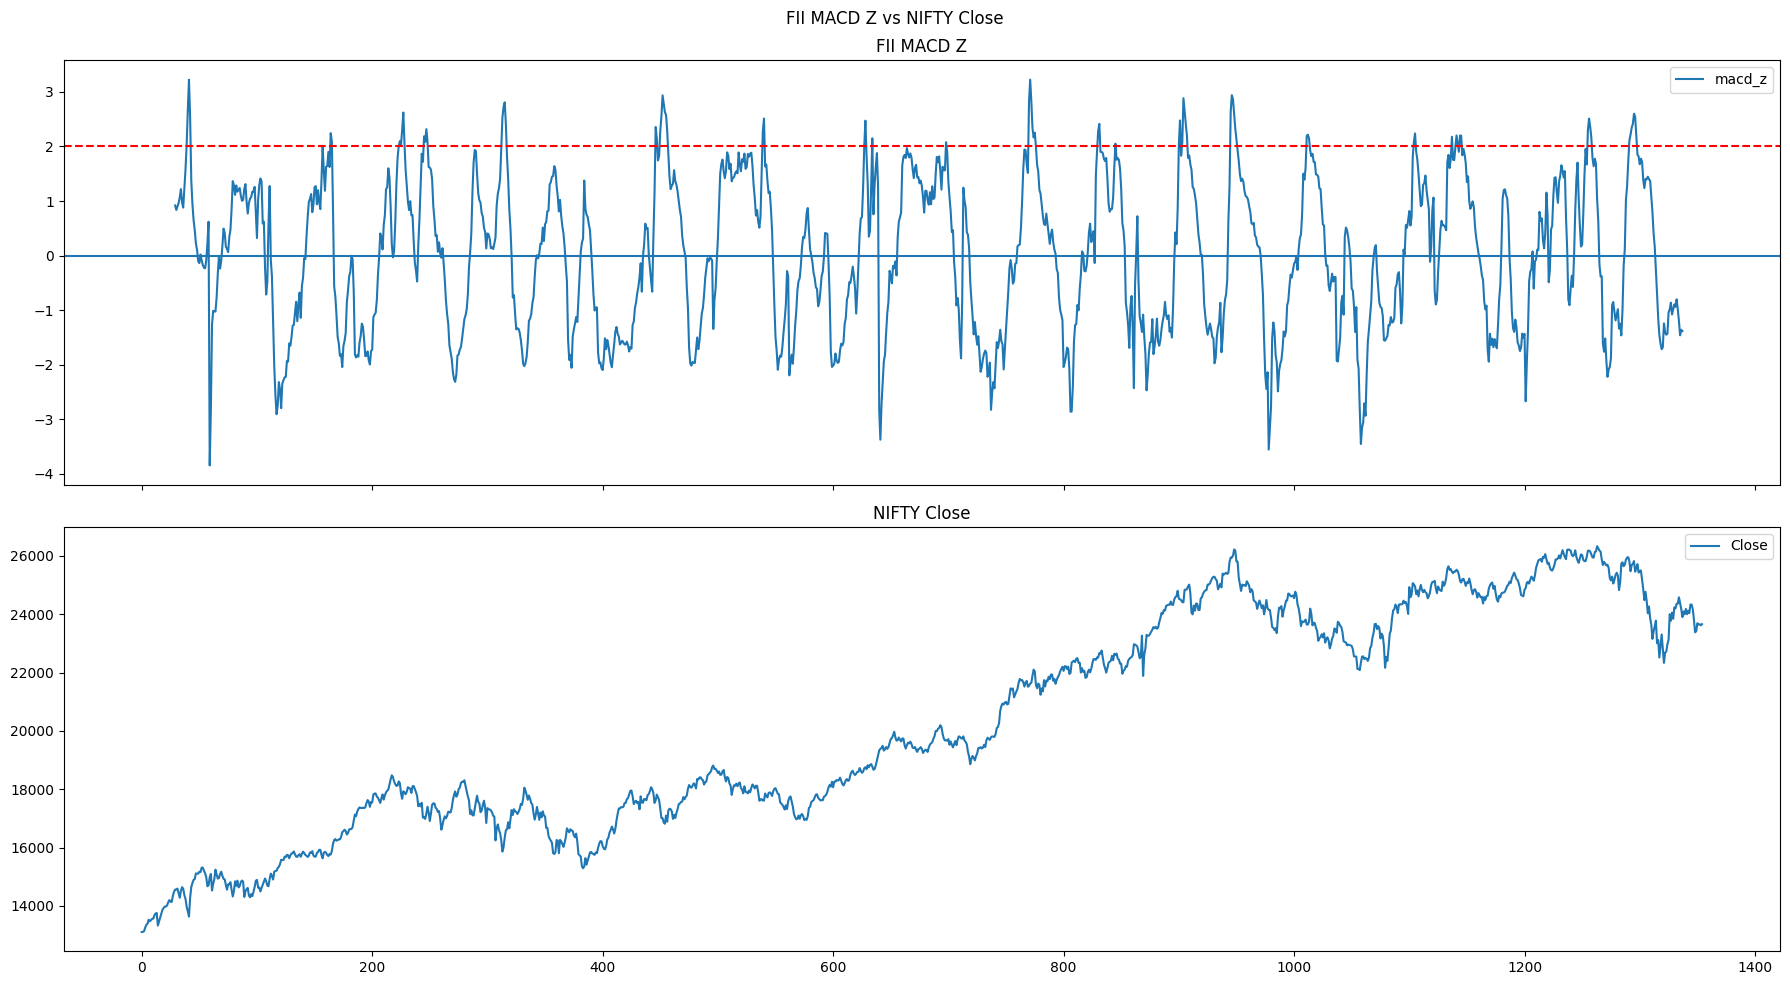

In [69]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# First subplot
fii_fig['macd_z'].plot(ax=axes[0])
axes[0].axhline(y=0)
axes[0].set_title('FII MACD Z')
axes[0].legend(['macd_z'])
axes[0].axhline(y=2, color='red', linestyle='--')

# Second subplot
nif['Close'].plot(ax=axes[1])
axes[1].set_title('NIFTY Close')
axes[1].legend(['Close'])

plt.suptitle('FII MACD Z vs NIFTY Close')
plt.tight_layout()

plt.show()

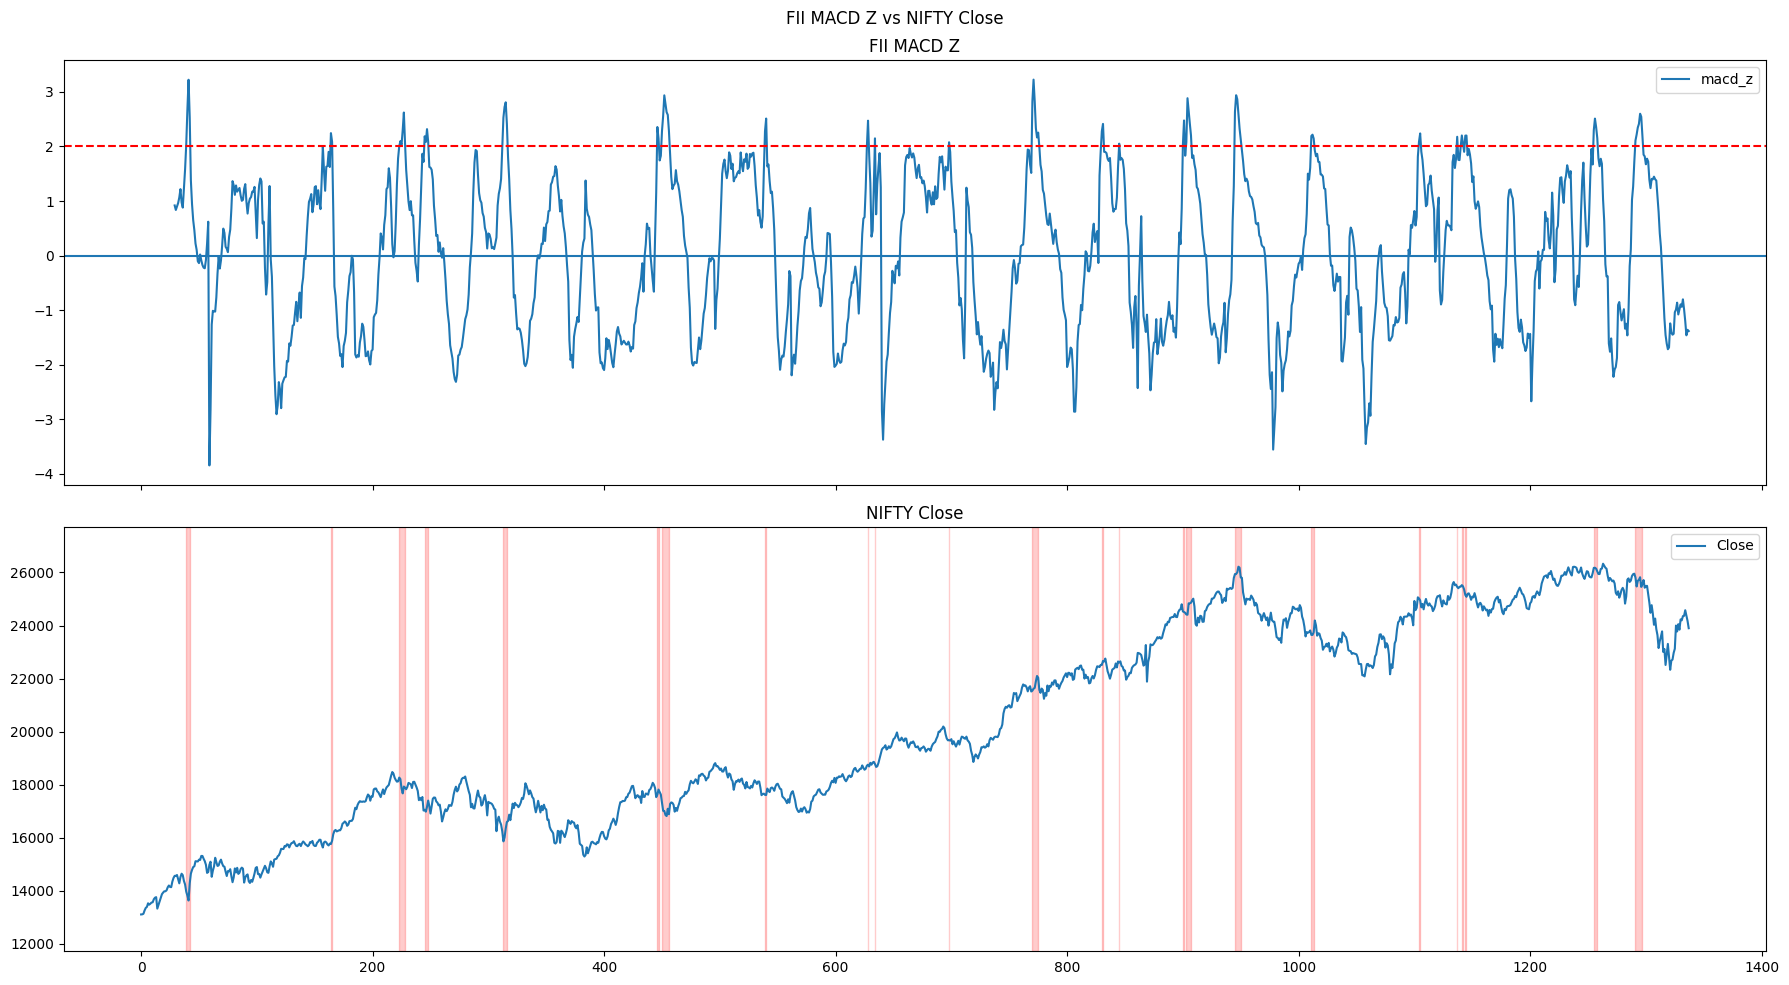

In [71]:
# Align both dataframes on common index
combined = pd.concat(
    [fii_fig['macd_z'], nif['Close']],
    axis=1,
    join='inner'
)

combined.columns = ['macd_z', 'Close']

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# --- First subplot ---
combined['macd_z'].plot(ax=axes[0])

axes[0].axhline(y=0)
axes[0].axhline(y=2, color='r', linestyle='--')

axes[0].set_title('FII MACD Z')
axes[0].legend(['macd_z'])

# --- Second subplot ---
combined['Close'].plot(ax=axes[1])

# Condition
condition = combined['macd_z'] > 2

# Red background
axes[1].fill_between(
    combined.index,
    0,
    1,
    where=condition,
    color='red',
    alpha=0.2,
    transform=axes[1].get_xaxis_transform()
)

axes[1].set_title('NIFTY Close')
axes[1].legend(['Close'])

plt.suptitle('FII MACD Z vs NIFTY Close')

plt.tight_layout()
plt.show()

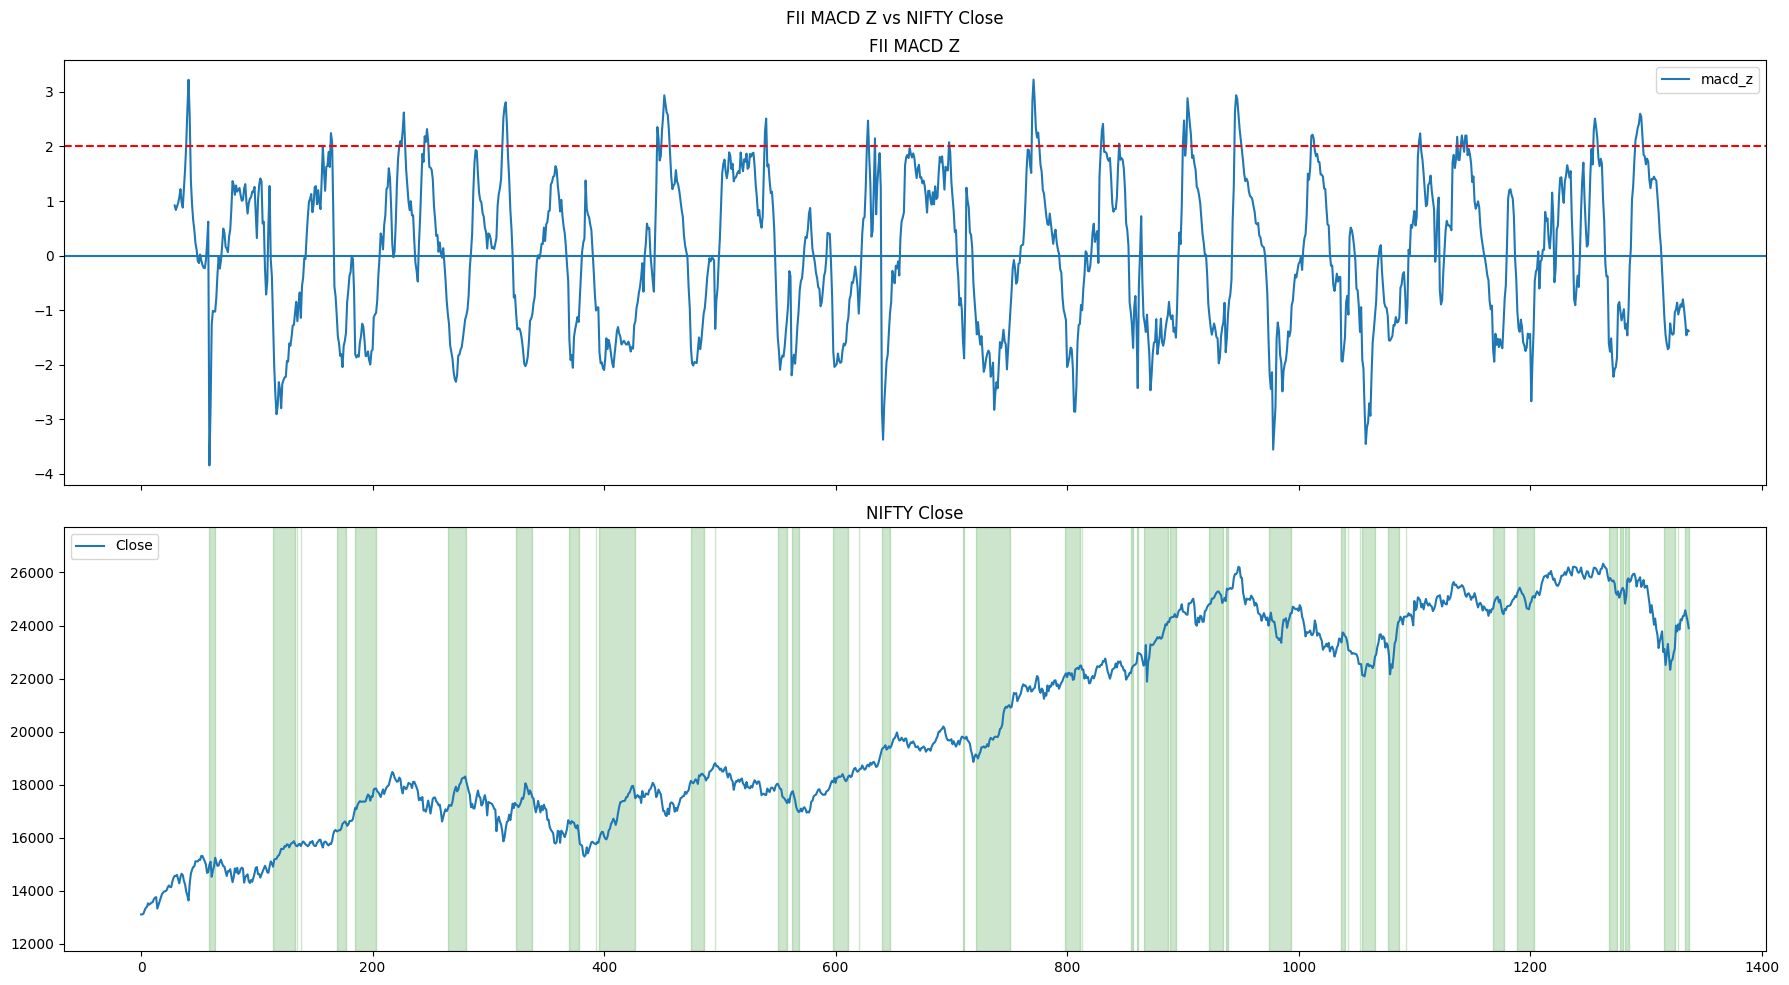

In [75]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# --- First subplot ---
combined['macd_z'].plot(ax=axes[0])

axes[0].axhline(y=0)
axes[0].axhline(y=2, color='r', linestyle='--')

axes[0].set_title('FII MACD Z')
axes[0].legend(['macd_z'])

# --- Second subplot ---
combined['Close'].plot(ax=axes[1])

# Condition
condition = combined['macd_z'] < -1

# Red background
axes[1].fill_between(
    combined.index,
    0,
    1,
    where=condition,
    color='green',
    alpha=0.2,
    transform=axes[1].get_xaxis_transform()
)

axes[1].set_title('NIFTY Close')
axes[1].legend(['Close'])

plt.suptitle('FII MACD Z vs NIFTY Close')

plt.tight_layout()
plt.show()

In [28]:
fii_fig['macd_regime'] = pd.cut(
    fii_fig['macd_z'],
    bins=[-np.inf,-1,-0.5,0,0.5,1,np.inf],
    labels=[
        'panic_selling',
        'strong_selling',
        'weak_selling',
        'weak_buying',
        'strong_buying',
        'euphoria'
    ]
)

In [29]:
fii_fig['ret_10d'] = (fii_fig['Close'].shift(-10) / fii_fig['Close'] - 1)*100

fii_fig.groupby('macd_regime')['ret_10d'].mean()

,ret_10d
macd_regime,
panic_selling,0.403282
strong_selling,0.809615
weak_selling,0.293659
weak_buying,-0.137919
strong_buying,0.312092
euphoria,0.658810


In [30]:
#fii_fig["Date"] = pd.to_datetime(fii_fig["Date"])

regime_slice = (
    fii_fig
    .set_index("Date")
    .loc[:, ["macd_regime","ret_10d"]]
)

In [31]:
regime_slice.tail(5)

,macd_regime,ret_10d
Date,,
2026-05-14,weak_buying,NaN
2026-05-15,strong_buying,NaN
2026-05-18,euphoria,NaN
2026-05-19,euphoria,NaN
2026-05-20,euphoria,NaN


In [32]:
fii_fig['macd_regime'].iloc[-1]

'euphoria'

In [33]:
fii_fig.groupby('macd_regime')['ret_10d'].median()*100

,ret_10d
macd_regime,
panic_selling,43.846280
strong_selling,104.214601
weak_selling,9.333373
weak_buying,-8.272944
strong_buying,55.903592
euphoria,101.154234


In [34]:
fii_fig['trend_regime'] = np.where(
    fii_fig['Close'] > fii_fig['MA20'],
    'above_MA20',
    'below_MA20'
)

In [35]:
pd.pivot_table(
    fii_fig,
    values='ret_10d',
    index='macd_regime',
    columns='trend_regime',
    aggfunc='mean'
)

trend_regime,above_MA20,below_MA20
macd_regime,,
panic_selling,-0.023847,0.550230
strong_selling,0.154405,1.304508
weak_selling,0.021078,0.623829
weak_buying,0.079510,-0.560351
strong_buying,0.197494,0.634058
euphoria,0.806874,-2.746660


In [36]:
# MACD crossover conditions
fii_fig['macd_cross_up'] = (
    (fii_fig['macd'] > fii_fig['signal']) &
    (fii_fig['macd'].shift(1) <= fii_fig['signal'].shift(1))
)

fii_fig['macd_cross_down'] = (
    (fii_fig['macd'] < fii_fig['signal']) &
    (fii_fig['macd'].shift(1) >= fii_fig['signal'].shift(1))
)

In [37]:
fii_fig['ret_10d'] = fii_fig['Close'].shift(-20) / fii_fig['Close'] - 1

In [38]:

fii_fig['macd_event'] = np.select(
    [fii_fig['macd_cross_up'], fii_fig['macd_cross_down']],
    ['bullish_cross', 'bearish_cross'],
    default='no_cross'
)

In [39]:
result = fii_fig.groupby('macd_event')['ret_10d'].agg(
    count='count',
    mean='mean',
    median='median',
    win_rate=lambda x: (x > 0).mean()
)

print(result)

               count      mean    median  win_rate
macd_event                                        
bearish_cross     75  0.008297  0.009475  0.631579
bullish_cross     75  0.009213  0.009915  0.552632
no_cross        1168  0.009536  0.009148  0.604553


In [40]:
fii_fig['position'] = 0

fii_fig.loc[fii_fig['macd_cross_up'], 'position'] = 1
fii_fig.loc[fii_fig['macd_cross_down'], 'position'] = 0

fii_fig['position'] = fii_fig['position'].replace(to_replace=0, method='ffill')

In [41]:
fii_fig['ret'] = fii_fig['Close'].pct_change()
fii_fig['strategy_ret'] = fii_fig['position'].shift(1) * fii_fig['ret']
performance = {
    "mean_daily_return": fii_fig['strategy_ret'].mean(),
    "total_return": (1 + fii_fig['strategy_ret']).prod() - 1,
    "win_rate": (fii_fig['strategy_ret'] > 0).mean()
}

print(performance)

{'mean_daily_return': np.float64(0.00045946304273394395), 'total_return': np.float64(0.7487489929115789), 'win_rate': np.float64(0.5306427503736921)}


In [42]:
fii_fig['ma50'] = fii_fig['Close'].rolling(20).mean()
fii_fig['fii_macd_bullish'] = fii_fig['macd'] > fii_fig['signal']

fii_fig['nifty_above_ma50'] = fii_fig['Close'] > fii_fig['ma50']

In [43]:
fii_fig['long_regime'] = (
    fii_fig['fii_macd_bullish'] &
    fii_fig['nifty_above_ma50']
)
fii_fig['position'] = fii_fig['long_regime'].astype(int)

In [44]:
fii_fig['ret'] = fii_fig['Close'].pct_change()

fii_fig['strategy_ret'] = fii_fig['position'].shift(1) * fii_fig['ret']

In [45]:
fii_fig['regime'] = np.where(
    fii_fig['fii_macd_bullish'] & fii_fig['nifty_above_ma50'],
    'bullish_flow_uptrend',
    'other'
)

print(
    fii_fig.groupby('regime')['ret']
    .agg(['count','mean','median',lambda x:(x>0).mean()])
)

                      count      mean    median  <lambda_0>
regime                                                     
bullish_flow_uptrend    520  0.002784  0.001907    0.655769
other                   817 -0.000981 -0.000758    0.458435


In [46]:
# 20 DMA
fii_fig['ma20'] = fii_fig['Close'].rolling(20).mean()

# distance from MA20
fii_fig['dist_ma20'] = (fii_fig['Close'] - fii_fig['ma20']) / fii_fig['ma20']

conditions = [
    fii_fig['dist_ma20'] > 0.02,
    fii_fig['dist_ma20'].between(0, 0.02),
    fii_fig['dist_ma20'] < 0
]

choices = [
    'strong_uptrend',
    'weak_uptrend',
    'bearish'
]

fii_fig['trend_regime'] = np.select(conditions, choices, default='neutral')

In [47]:

fii_fig['fii_macd_bullish'] = fii_fig['macd'] > fii_fig['signal']
fii_fig['regime'] = np.where(
    fii_fig['fii_macd_bullish'] & (fii_fig['dist_ma20'].between(0.03,1)),
    'flow_trend_bullish',
    'other'
)
fii_fig['ret'] = fii_fig['Close'].pct_change()

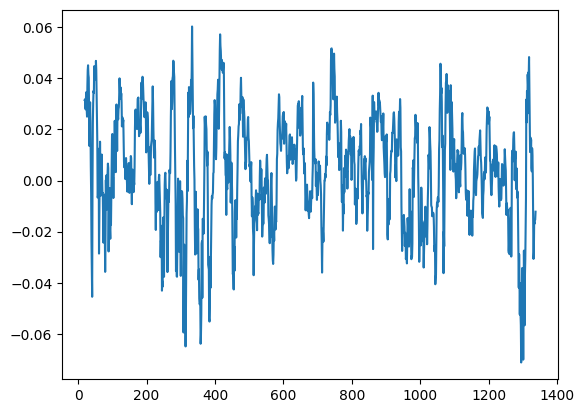

In [48]:
fii_fig['dist_ma20'].plot();

In [49]:
result = (
    fii_fig.groupby('regime')['ret']
    .agg(['count','mean','median',lambda x:(x>0).mean()])
)

print(result)

                    count      mean    median  <lambda_0>
regime                                                   
flow_trend_bullish    129  0.005202  0.005084    0.767442
other                1208 -0.000021  0.000136    0.510339


In [50]:
df = fii_fig[fii_fig['macd'] > 0].copy()

In [51]:


bins = [0,0.02,0.04,0.06,0.08,.1]

df['dist_bin'] = pd.cut(df['dist_ma20'], bins=bins)

In [52]:
df['ret'] = df['Close'].pct_change()

In [53]:
result = (
    df.groupby('dist_bin')['ret']
    .agg(
        count='count',
        mean='mean',
        median='median',
        win_rate=lambda x:(x>0).mean()
    )
)

print(result)


              count      mean    median  win_rate
dist_bin                                         
(0.0, 0.02]     232  0.000157  0.000538  0.540773
(0.02, 0.04]    142  0.004098  0.003612  0.739437
(0.04, 0.06]     30  0.005708  0.005318  0.866667
(0.06, 0.08]      1  0.021672  0.021672  1.000000
(0.08, 0.1]       0       NaN       NaN       NaN


In [54]:
df = fii_fig[fii_fig['macd'] <= 0].copy()

In [55]:
bins = [-.1,-0.08,-0.06,-0.04,-0.02,0]

df['dist_bin'] = pd.cut(df['dist_ma20'], bins=bins)

In [56]:
result = (
    df.groupby('dist_bin')['ret']
    .agg(
        count='count',
        mean='mean',
        median='median',
        win_rate=lambda x:(x>0).mean()
    )
)

print(result)


                count      mean    median  win_rate
dist_bin                                           
(-0.1, -0.08]       0       NaN       NaN       NaN
(-0.08, -0.06]      6 -0.021113 -0.022869  0.000000
(-0.06, -0.04]     30 -0.009001 -0.009145  0.266667
(-0.04, -0.02]    116 -0.005042 -0.004893  0.301724
(-0.02, 0.0]      294 -0.000469 -0.001365  0.404762


In [57]:
fii_fig["exit_signal"] = fii_fig["Close"] < fii_fig["ma20"]

In [58]:
fii_fig["entry_signal"] = (
    (fii_fig["Close"] > fii_fig["ma20"]) &
    (fii_fig["macd"] > fii_fig['signal10']) &
    #(fii_fig["dist_ma20"] > 0) &
    (fii_fig["impulse"] == "green")
)

In [59]:
position = 0
entry_price = 0

trades = []

for i in range(len(fii_fig)):

    price = fii_fig["Close"].iloc[i]

    if position == 0:

        if fii_fig["entry_signal"].iloc[i]:
            position = 1
            entry_price = price
            entry_date = fii_fig.index[i]

    elif position == 1:

        if fii_fig["exit_signal"].iloc[i]:

            exit_price = price
            exit_date = fii_fig.index[i]

            ret = (exit_price / entry_price) - 1

            trades.append({
                "entry_date": entry_date,
                "exit_date": exit_date,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "return": ret
            })

            position = 0

In [60]:
trades_df = pd.DataFrame(trades)

In [61]:
fii_fig.columns

Index(['index', 'Date', 'FIICash', 'DIIcash', 'Open', 'High', 'Low', 'Close',
       'Volume', 'Cash', 'Cashfut', 'signalfutcash', 'signal10futcash',
       'macdy', 'signaly', 'signal10y', 'histy', 'macd', 'signal', 'signal10',
       'hist', 'macdx', 'signalx', 'signal10x', 'histx', 'macd_dom',
       'signal_dom', 'signal_dom_10', 'hist_dom', 'MA200', 'MA20', 'MA13',
       'MA26', 'MA12', 'macd_impulse', 'macd_signal', 'macd_hist', 'ema_slope',
       'macd_slope', 'impulse', 'macd_z', 'macd_regime', 'ret_10d',
       'trend_regime', 'macd_cross_up', 'macd_cross_down', 'macd_event',
       'position', 'ret', 'strategy_ret', 'ma50', 'fii_macd_bullish',
       'nifty_above_ma50', 'long_regime', 'regime', 'ma20', 'dist_ma20',
       'exit_signal', 'entry_signal'],
      dtype='object')

In [62]:
print(fii_fig['macd_regime'].tail(1))
print('\n\n\n')
print(fii_fig['trend_regime'].tail(1))

1337    euphoria
Name: macd_regime, dtype: category
Categories (6, object): ['panic_selling' < 'strong_selling' < 'weak_selling' < 'weak_buying' <
                         'strong_buying' < 'euphoria']




1337    bearish
Name: trend_regime, dtype: object


In [63]:
stats = {
    "trades": len(trades_df),
    "mean_return": trades_df["return"].mean(),
    "median_return": trades_df["return"].median(),
    "win_rate": (trades_df["return"] > 0).mean(),
    "max_gain": trades_df["return"].max(),
    "max_loss": trades_df["return"].min(),
}

print(stats)

{'trades': 43, 'mean_return': np.float64(0.006693816459262325), 'median_return': -0.007079275263927043, 'win_rate': np.float64(0.3953488372093023), 'max_gain': 0.11050508742442222, 'max_loss': -0.04715980955822652}
